# Carga y filtro de datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import rna_utils as ru
from rna_utils import order_families, order_matrix
import math

DATA_PATH    = "/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/data/" 

DIST_PATH = DATA_PATH + "rnadist_f_all.h5"
META_PATH = DATA_PATH + "sources/ArchiveII_with_prob_and_motiv.csv"

In [2]:
dist, meta = ru.load_and_align(corr_path=DIST_PATH, meta_path=META_PATH)
display(meta.head())
display(dist.head())

,sequence,structure,base_pairs,len,motivos,fam,pseudo_probe,stem
id,,,,,,,,
16s_A.fulgidus_domain2,UUUAUUGGGCCUAAAGCGUCCGUAGCCGGGCUGGUAAGUCCUCCGG...,.......(((<<...(.((((.(.(((.(((((((.((((((((((...,"[[8, 329], [9, 328], [10, 327], [11, 312], [12...",359,EEEEEEESSSBBBBBSMSSSSISBSSSMSSSSSSSBSSSSSSSSSS...,16s,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, ..."
16s_A.fulgidus_domain3,AAGGAAUUGGCGGGGGAGCACUACAACGGGUGGAGCCUGCGGUUUA...,.......(((((.(((((((..((..((((((.((((((((((......,"[[8, 487], [9, 486], [10, 484], [11, 483], [12...",488,EEEEEEESSSSSBSSSSSSSIISSMMSSSSSSISSSSSSSSSSMMM...,16s,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, ..."
16s_A.fulgidus_domain4,ACCGCCCGUCAAGCCACCCGAGUGGGCCAGGGGCGAGGGGGUGGCC...,.(.(..((...((((.(((..(((((((..((((..((((((((((...,"[[2, 97], [4, 94], [7, 90], [8, 89], [12, 84],...",133,ESISIISSIIISSSSISSSIISSSSSSSIISSSSIISSSSSSSSSS...,16s,"[0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, ..."
16s_A.pyrophilus_domain2,UCACUGGGCGUAAAGCGUCCGCAGCCGGUCGGGUAAGCGGGAUGUC...,................((((...(((.(((((((.(((((((((((...,"[[17, 204], [18, 203], [19, 202], [20, 201], [...",250,EEEEEEEEEEEEEEEESSSSIIISSSMSSSSSSSBSSSSSSSSSSS...,16s,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
16s_A.pyrophilus_domain4,CCGCCCGUCACGCCACGGAAGUCGGUCCGGCCGGAAGUCCCCGAGC...,..(..((...((((.(((..((((((((((((....(.((((..((...,"[[3, 114], [6, 110], [7, 109], [11, 104], [12,...",137,EESIISSIIISSSSISSSIISSSSSSSSSSSSIIIISISSSSIISS...,16s,"[0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, ...","[0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, ..."


id,16s_A.fulgidus_domain2,16s_A.fulgidus_domain3,16s_A.fulgidus_domain4,16s_A.pyrophilus_domain2,16s_A.pyrophilus_domain4,16s_B.burgdorferi_domain2,16s_B.burgdorferi_domain3,16s_B.burgdorferi_domain4,16s_B.subtilis_domain2,16s_B.subtilis_domain3,...,tmRNA_uncu.bact._TRW-32033-1_1-354,tmRNA_uncu.bact._TRW-32045-4_1-369,tmRNA_uncu.bact._TRW-383630-1_1-364,tmRNA_uncu.bact._TRW-45456_1-408,tmRNA_uncu.bact._TRW-72274-1_1-359,tmRNA_uncu.bact._TRW-72274-2_1-359,tmRNA_uncu.bact._TRW-80840-1_1-378,tmRNA_uncu.bact._TRW-80840-2_1-379,tmRNA_uncu.bact._TRW-80840-3_1-379,tmRNA_uncu.mari._TRW-363180_1-347
id,,,,,,,,,,,,,,,,,,,,,
16s_A.fulgidus_domain2,0.000000,0.661885,0.685237,0.387187,0.729805,0.116992,0.647423,0.674095,0.089136,0.666667,...,0.805014,0.888889,0.898352,0.762255,0.896936,0.841226,0.791005,0.791557,0.817942,0.785515
16s_A.fulgidus_domain3,0.661885,0.000000,0.743852,0.688525,0.752049,0.629098,0.141393,0.731557,0.641393,0.116803,...,0.672131,0.649590,0.668033,0.672131,0.670082,0.678279,0.680328,0.678279,0.682377,0.674180
16s_A.fulgidus_domain4,0.685237,0.743852,0.000000,0.668000,0.379562,0.670487,0.754639,0.176871,0.670423,0.753623,...,0.827684,0.829268,0.821429,0.845588,0.835655,0.813370,0.822751,0.823219,0.828496,0.829971
16s_A.pyrophilus_domain2,0.387187,0.688525,0.668000,0.000000,0.660000,0.318052,0.678351,0.628000,0.363380,0.701863,...,0.836158,0.788618,0.813187,0.818627,0.832869,0.805014,0.788360,0.778364,0.794195,0.798271
16s_A.pyrophilus_domain4,0.729805,0.752049,0.379562,0.660000,0.000000,0.722063,0.758763,0.326531,0.726761,0.757764,...,0.793785,0.802168,0.815934,0.811275,0.802228,0.774373,0.780423,0.781003,0.781003,0.812680


In [3]:
fams = ru.build_intra_fam_corrs(dist, meta) 
distances = ru.build_intra_fam_corrs(dist, meta)
corrs_summary = ru.summary_table(distances)

In [4]:
dist_filt = ru.filter_struc_by_count_dict(distances, data_size=1500, verbose=True)
dist_filt400 = ru.filter_struc_by_count_dict(distances, data_size=400)
dist_filt200 = ru.filter_struc_by_count_dict(distances, data_size=200)
dist_filt100 = ru.filter_struc_by_count_dict(distances, data_size=100)

Initial shape: 66^2
Data size (1500) is larger than matrix size (66), ignoring family.
Initial shape: 15^2
Data size (1500) is larger than matrix size (15), ignoring family.
Initial shape: 1283^2
Data size (1500) is larger than matrix size (1283), ignoring family.
Initial shape: 454^2
Data size (1500) is larger than matrix size (454), ignoring family.
Initial shape: 74^2
Data size (1500) is larger than matrix size (74), ignoring family.
Initial shape: 918^2
Data size (1500) is larger than matrix size (918), ignoring family.
Initial shape: 557^2
Data size (1500) is larger than matrix size (557), ignoring family.
Initial shape: 35^2
Data size (1500) is larger than matrix size (35), ignoring family.
Initial shape: 462^2
Data size (1500) is larger than matrix size (462), ignoring family.
Initial shape: 66^2
Data size (400) is larger than matrix size (66), ignoring family.
Initial shape: 15^2
Data size (400) is larger than matrix size (15), ignoring family.
Initial shape: 1283^2
Data size s

# Analisis y plots

In [5]:
dist400_summary = ru.summary_table(dist_filt400)
dist200_summary = ru.summary_table(dist_filt200)
dist100_summary = ru.summary_table(dist_filt100)
#display(dist400_summary)
#display(dist200_summary)
#display(dist100_summary)

In [6]:
# 4) resumen tabular
corrs_filt_summary = ru.summary_table(dist_filt400)
#print(60 * "-")
#print(corrs_filt_summary.n_seq.sum().item())
#print(100 * corrs_filt_summary.n_seq.sum().item() / corrs_summary.n_seq.sum().item())
#display(corrs_filt_summary)
#print(60 * "-")
#display(ru.relative_summary_table(corrs_summary, corrs_filt_summary))

In [7]:
dist_filt.keys()

dict_keys(['16s', '23s', '5s', 'RNaseP', 'grp1', 'srp', 'tRNA', 'telomerase', 'tmRNA'])

In [8]:
keys_keep = ['5s', 'RNaseP', 'srp', 'tRNA',  'tmRNA']

selected_dists = {k: dist_filt[k] for k in keys_keep}
selected_dists100 = {k: dist_filt100[k] for k in keys_keep}
selected_dists200 = {k: dist_filt200[k] for k in keys_keep}
selected_dists400 = {k: dist_filt400[k] for k in keys_keep}

In [9]:
from matplotlib.colors import PowerNorm
def plot_compare_heatmaps(
    corrs1,
    corrs2,
    n_fams=5,
    order_method="mean",
    figsize_scale=(4, 3),
    order_fams=False,
    normalized=False,
    title=None
):
    """
    Compara dos diccionarios de matrices:
    Cada fila corresponde a una familia.
    Columna 0: heatmap de corrs1[fam]
    Columna 1: heatmap de corrs2[fam]
    """
    import math
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    # Orden de familias (misma lógica que antes)
    ordered1 = order_families(corrs1, fixed=order_fams)
    ordered2 = order_families(corrs2, fixed=order_fams)

    # Asegurar que ambas listas tengan las mismas families
    fams = [f for f in ordered1 if f in ordered2][:n_fams]
    n_rows = len(fams)

    fig = plt.figure(
        figsize=(figsize_scale[0] * 2 + 1.2, figsize_scale[1] * n_rows)
    )
    gs = gridspec.GridSpec(
        n_rows,
        3,  # col0 corr1, col1 corr2, col2 colorbar
        width_ratios=[1, 1, 0.06],
        wspace=0.05,
        hspace=0.25,
    )

    last_im = None

    for row_idx, fam in enumerate(fams):

        # --------- Matrices ---------
        mat1 = order_matrix(corrs1[fam], method=order_method)
        mat2 = order_matrix(corrs2[fam], method=order_method)

        if normalized:
            mat1 = mat1 / 1.40625
            mat2 = mat2 / 1.40625


        # --------- columna 0 → corrs1 ---------
        ax1 = fig.add_subplot(gs[row_idx, 0])
        last_im = ax1.imshow(
            mat1.values, aspect="auto", cmap="viridis", vmin=0, vmax=0.7,
 #         norm=PowerNorm(gamma=0.5)
        )
        ax1.set_title(f"{mat1.shape[0]} seqs", fontsize=12)
        ax1.set_xticks([]), ax1.set_yticks([])
        ax1.set_ylabel(fam, fontsize=12)

        # --------- columna 1 → corrs2 ---------
        ax2 = fig.add_subplot(gs[row_idx, 1])
        ax2.imshow(
            mat2.values, aspect="auto", cmap="viridis", vmin=0, vmax=0.7,
#          norm=PowerNorm(gamma=0.5)
        )
        ax2.set_title(f"{mat2.shape[0]} seqs", fontsize=12)
        ax2.set_xticks([]), ax2.set_yticks([])

    # --------- barra de color única ---------
    cax = fig.add_subplot(gs[:, 2])
    fig.colorbar(last_im, cax=cax, label="Distance")

    # --------- título ---------
    if title is None:
        title = "Comparison of structural distance between two datasets"

    fig.suptitle(title, y=0.95, fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.96, 0.92])
    plt.show()


/tmp/ipykernel_2310701/2487012742.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.96, 0.92])


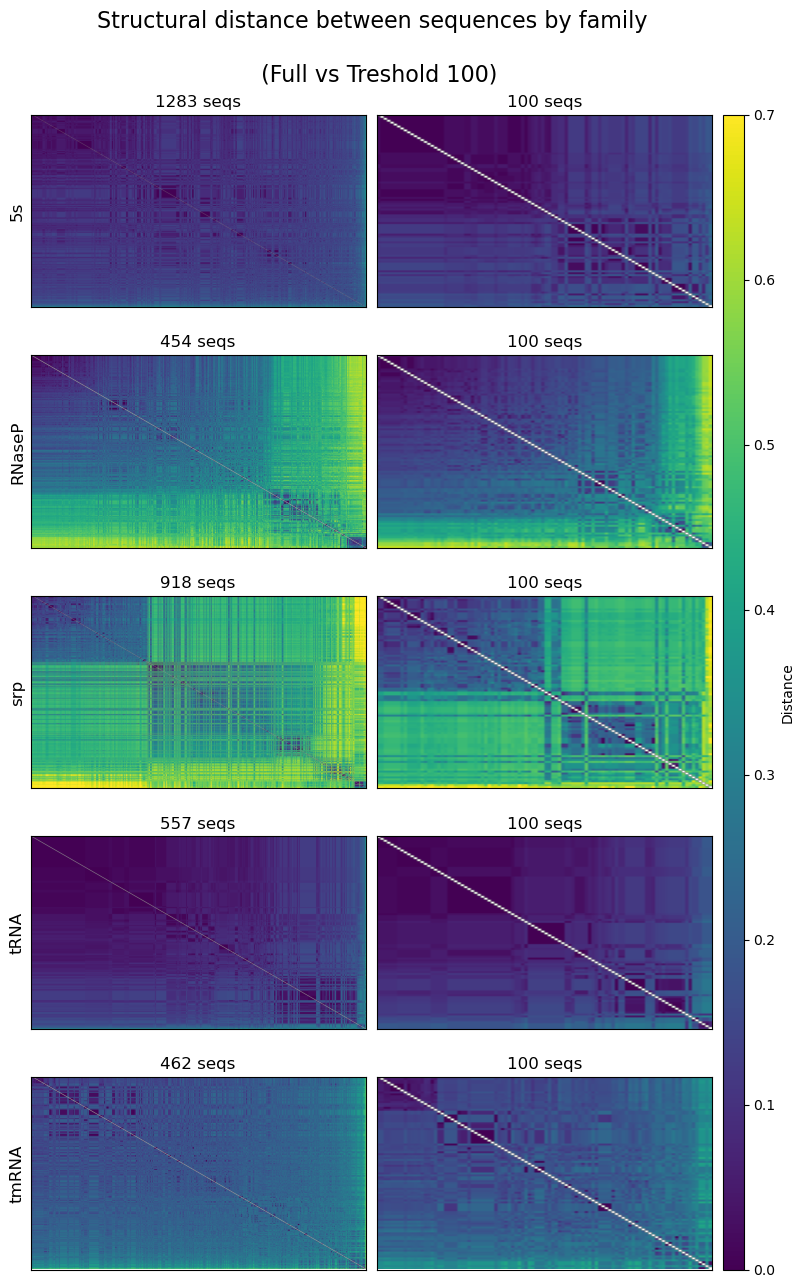

In [10]:
plot_compare_heatmaps(selected_dists, selected_dists100, n_fams=5, order_fams=True, normalized=True, title="Structural distance between sequences by family \n\n (Full vs Treshold 100)")

In [11]:
from matplotlib.colors import PowerNorm
def plot_compare_all_heatmaps(
    corrs1,
    corrs2,
    corrs3,
    corrs4,
    n_fams=5,
    order_method="mean",
    figsize_scale=(4, 3),
    order_fams=False,
    normalized=False,
    title=None
):
    """
    Compara dos diccionarios de matrices:
    Cada fila corresponde a una familia.
    Columna 0: heatmap de corrs1[fam]
    Columna 1: heatmap de corrs2[fam]
    """
    import math
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    # Orden de familias (misma lógica que antes)
    ordered1 = order_families(corrs1, fixed=order_fams)
    ordered2 = order_families(corrs2, fixed=order_fams)
    ordered3 = order_families(corrs3, fixed=order_fams)
    ordered4 = order_families(corrs4, fixed=order_fams)

    # Asegurar que ambas listas tengan las mismas families
    fams = [f for f in ordered1 if f in ordered2][:n_fams]
    n_rows = len(fams)

    fig = plt.figure(
        figsize=(figsize_scale[0] * 4 + 1.2, figsize_scale[1] * n_rows)
    )
    gs = gridspec.GridSpec(
        n_rows,
        5,  # col0 corr1, col1 corr2, col2 colorbar
        width_ratios=[1, 1,1,1, 0.06],
        wspace=0.05,
        hspace=0.25,
    )

    last_im = None

    for row_idx, fam in enumerate(fams):

        # --------- Matrices ---------
        mat1 = order_matrix(corrs1[fam], method=order_method)
        mat2 = order_matrix(corrs2[fam], method=order_method)
        mat3 = order_matrix(corrs3[fam], method=order_method)
        mat4 = order_matrix(corrs4[fam], method=order_method)

        if normalized:
            mat1 = mat1 / 1.40625
            mat2 = mat2 / 1.40625
            mat3 = mat3 / 1.40625
            mat4 = mat4 / 1.40625


        # --------- columna 0 → corrs1 ---------
        ax1 = fig.add_subplot(gs[row_idx, 0])
        last_im = ax1.imshow(
            mat1.values, aspect="auto", cmap="viridis", vmin=0, vmax=0.7,
 #         norm=PowerNorm(gamma=0.5)
        )
        ax1.set_title(f"{mat1.shape[0]} seqs", fontsize=12)
        ax1.set_xticks([]), ax1.set_yticks([])
        ax1.set_ylabel(fam, fontsize=12)

        # --------- columna 1 → corrs2 ---------
        ax2 = fig.add_subplot(gs[row_idx, 3])
        ax2.imshow(
            mat2.values, aspect="auto", cmap="viridis", vmin=0, vmax=0.7,
#          norm=PowerNorm(gamma=0.5)
        )
        ax2.set_title(f"{mat2.shape[0]} seqs", fontsize=12)
        ax2.set_xticks([]), ax2.set_yticks([])
        
        ax3 = fig.add_subplot(gs[row_idx, 2])
        ax3.imshow(
            mat3.values, aspect="auto", cmap="viridis", vmin=0, vmax=0.7,
#          norm=PowerNorm(gamma=0.5)
        )
        ax3.set_title(f"{mat3.shape[0]} seqs", fontsize=12)
        ax3.set_xticks([]), ax3.set_yticks([])
        
        ax4 = fig.add_subplot(gs[row_idx, 1])
        ax4.imshow(
            mat4.values, aspect="auto", cmap="viridis", vmin=0, vmax=0.7,
#          norm=PowerNorm(gamma=0.5)
        )
        
        ax4.set_title(f"{mat4.shape[0]} seqs", fontsize=12)
        ax4.set_xticks([]), ax4.set_yticks([])
        

    # --------- barra de color única ---------
    cax = fig.add_subplot(gs[:, 4])
    fig.colorbar(last_im, cax=cax, label="Distance")

    # --------- título ---------
    if title is None:
        title = "Comparison of structural distance between two datasets"

    fig.suptitle(title, y=0.95, fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.96, 0.92])
    plt.show()


/tmp/ipykernel_2310701/3352049169.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.96, 0.92])


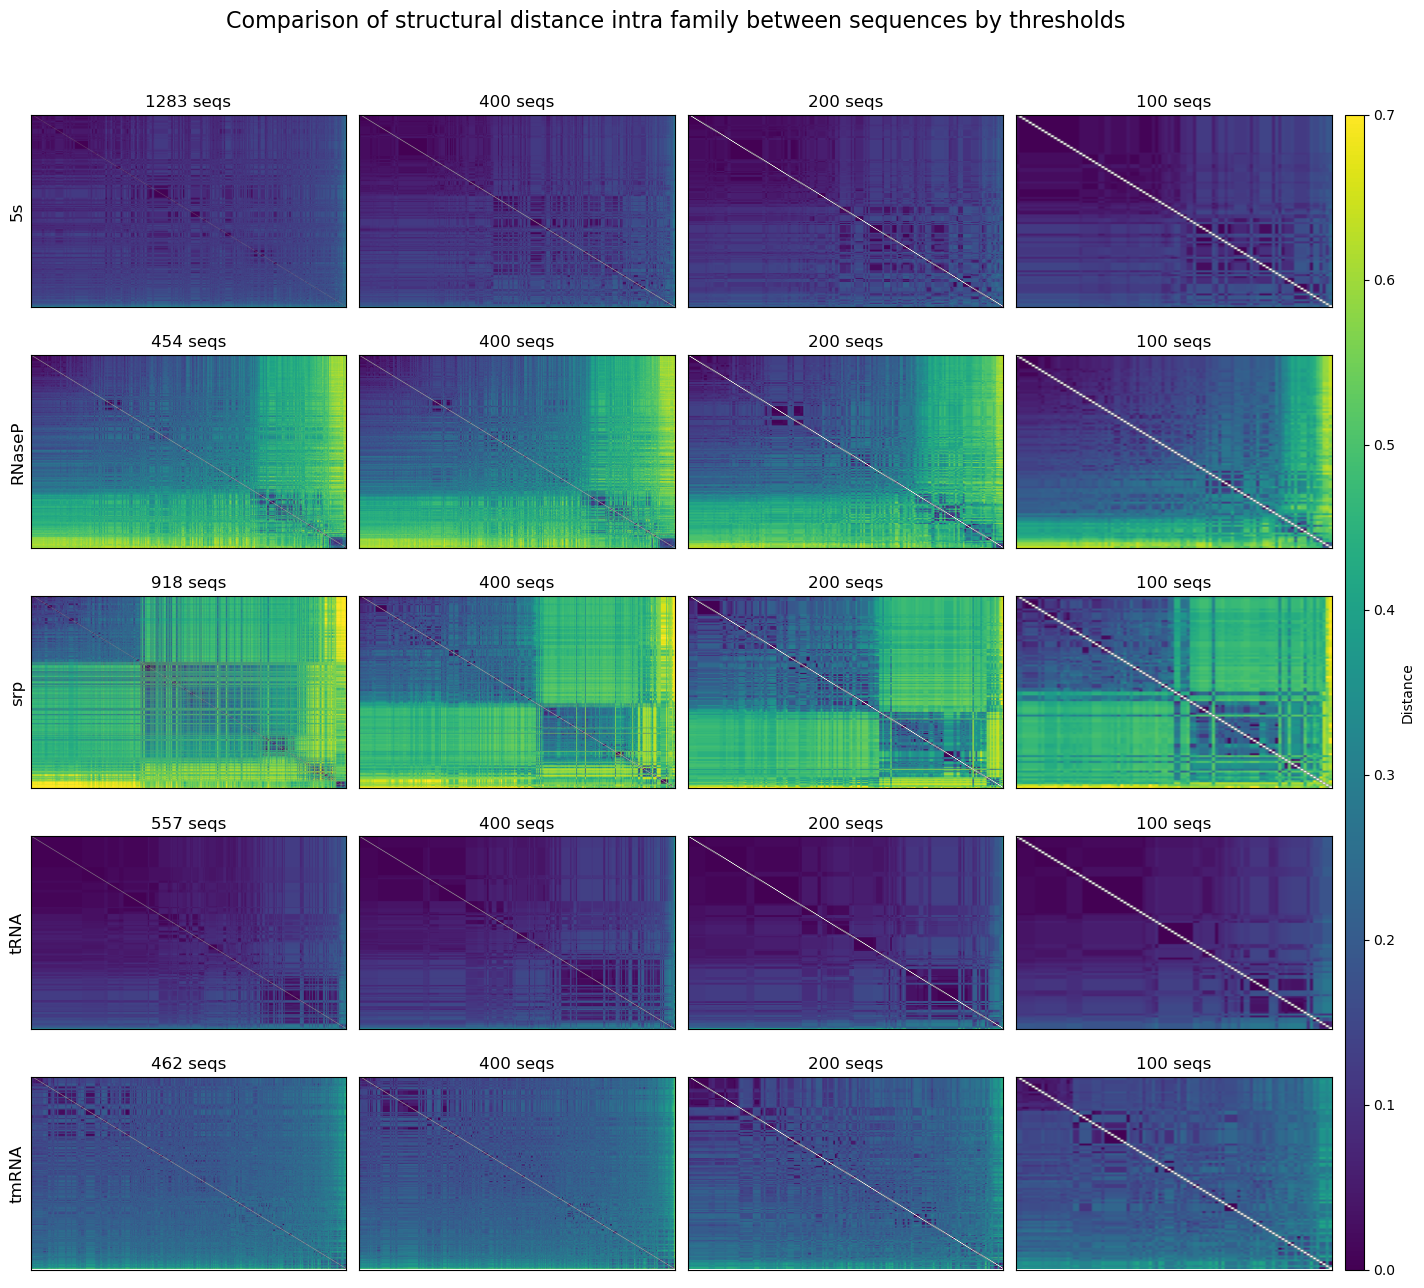

In [13]:
plot_compare_all_heatmaps(selected_dists, 
                      selected_dists100,
                        selected_dists200,
                        selected_dists400,
                      n_fams=5,
                      order_fams=True,
                      normalized=True, title="Comparison of structural distance intra family between sequences by thresholds")

/tmp/ipykernel_3114471/963409300.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.96, 0.9])


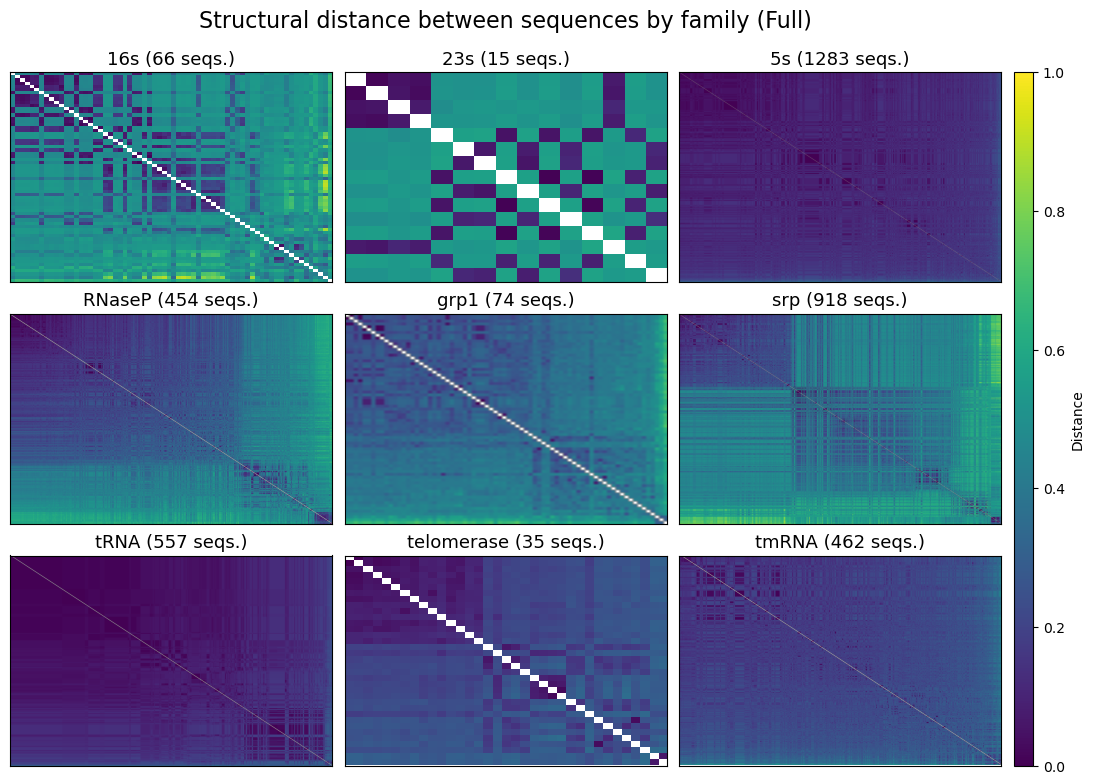

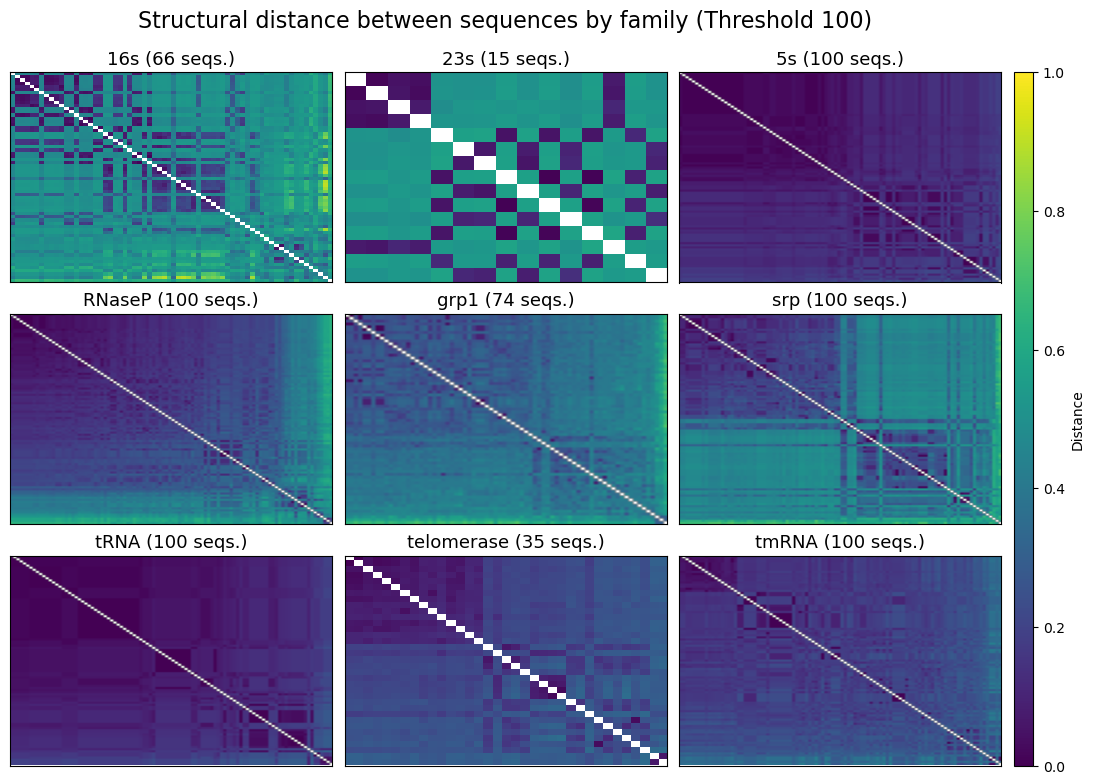

In [ ]:
# 5) visualización heatmaps + histogramas 
title_full = "Structural distance between sequences by family (Full)"
title_100 = "Structural distance between sequences by family (Threshold 100)"
plot_heatmaps_with_hist( , n_fams=8, order_fams=True, normalized=True, title=title_full) 
plot_heatmaps_with_hist(dist_filt100, n_fams=8, order_fams=True, normalized=True, title=title_100) 

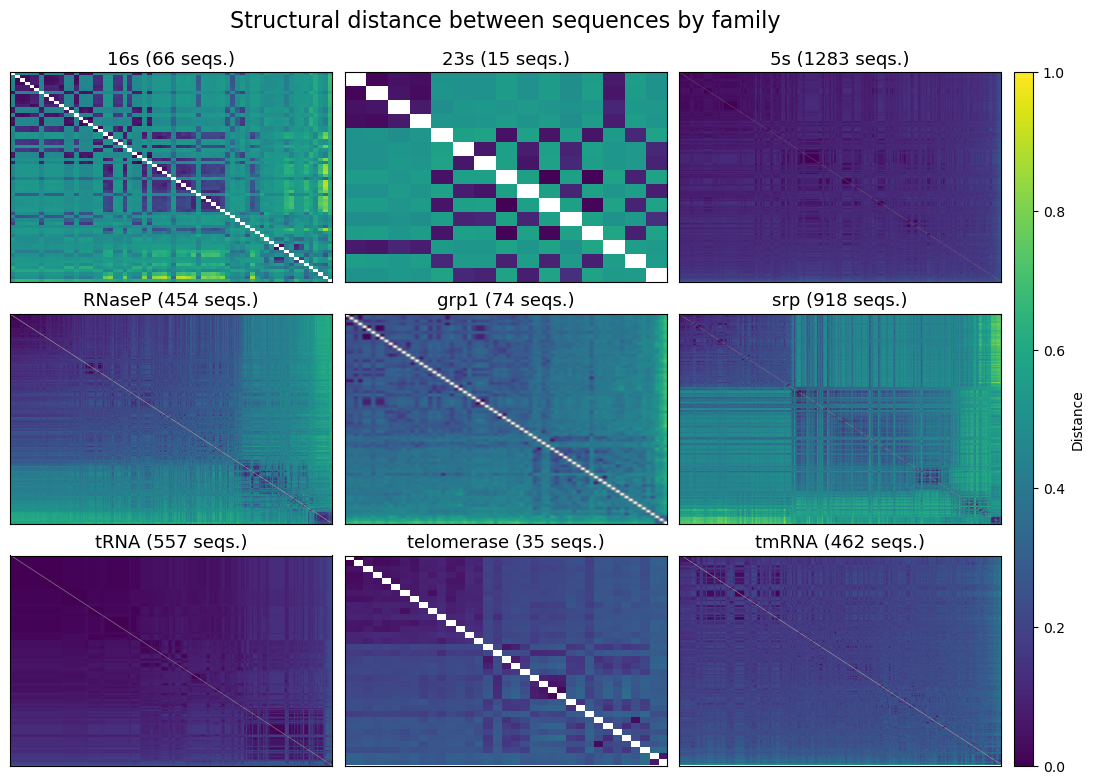

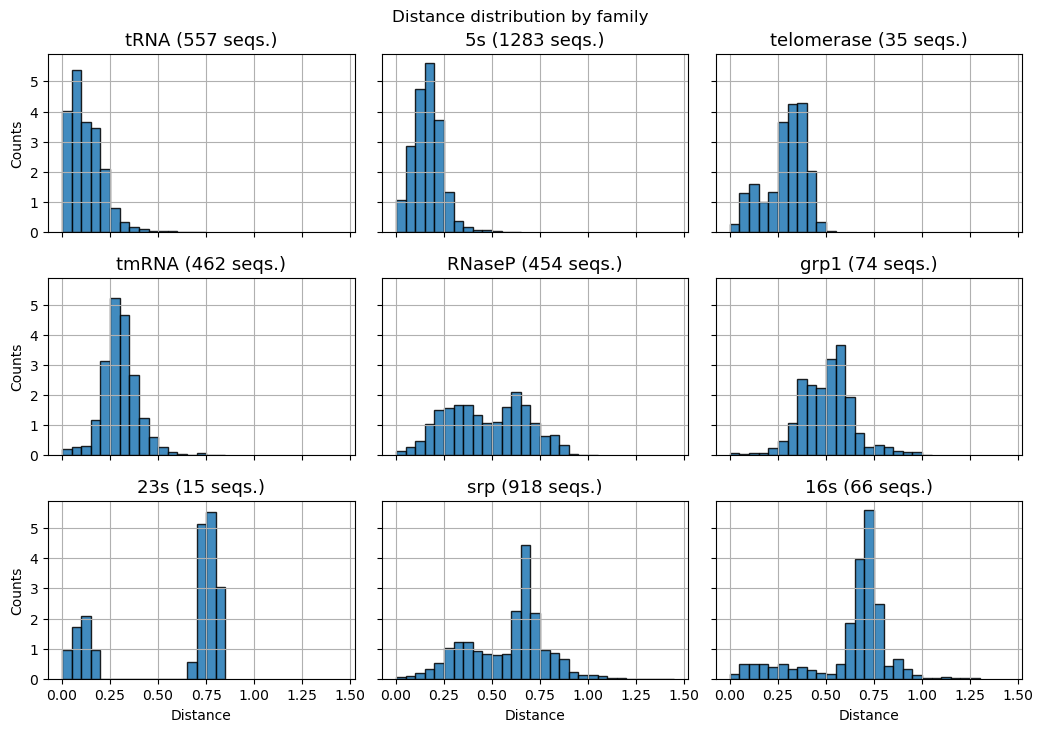

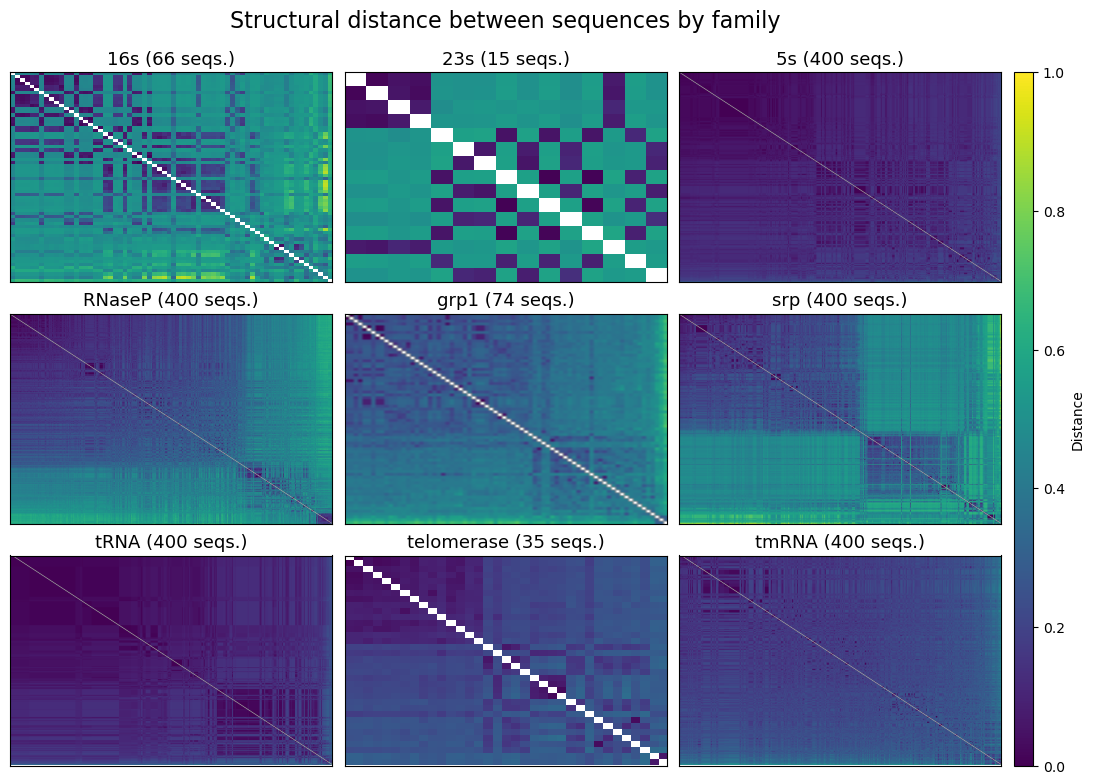

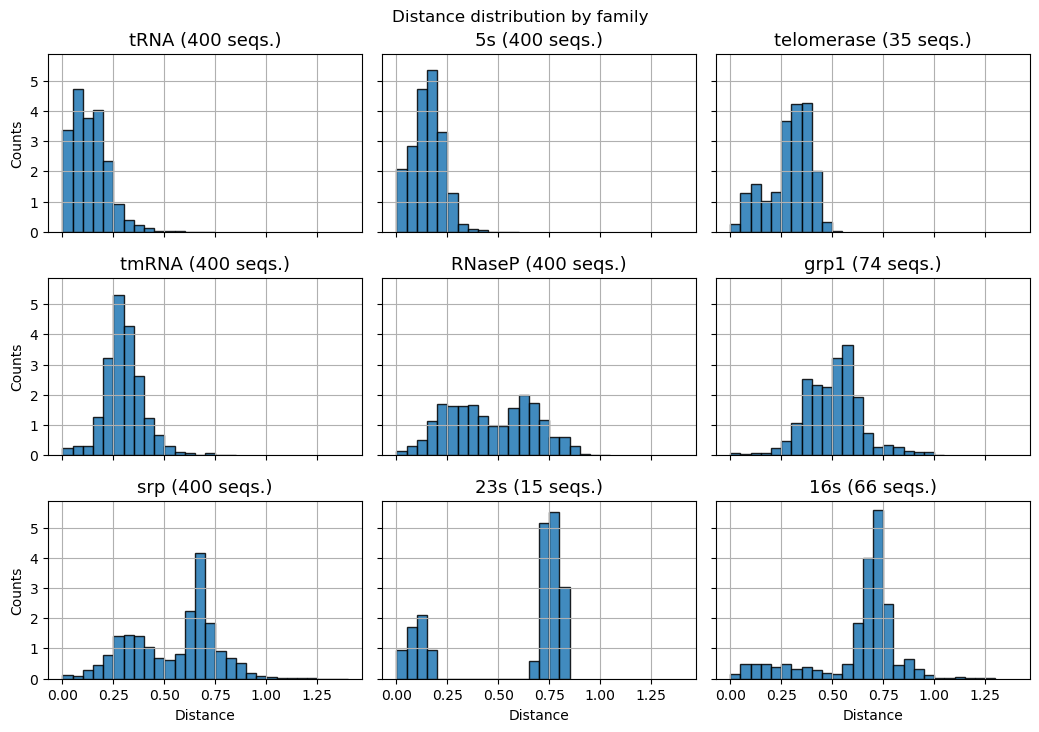

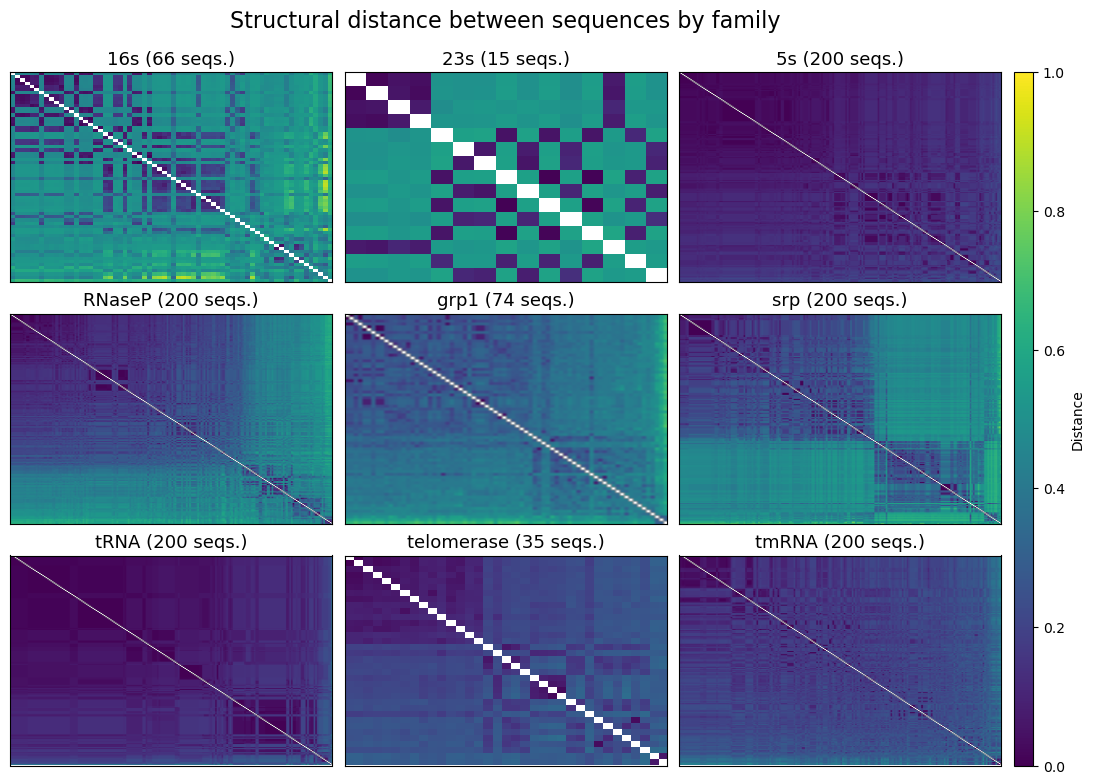

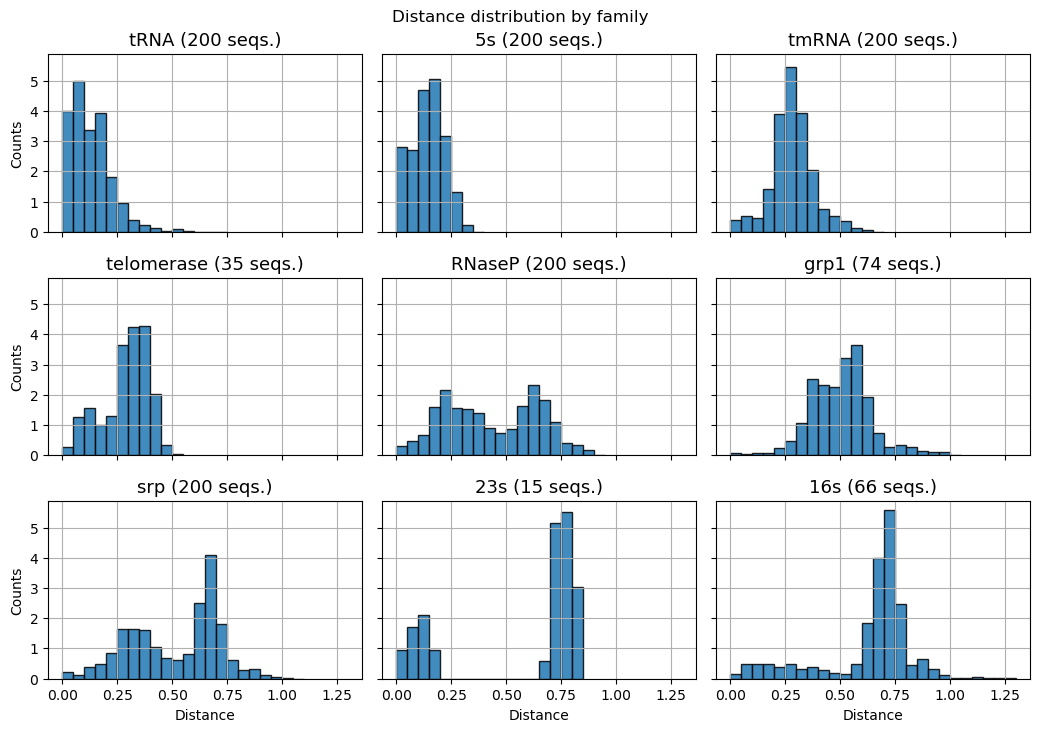

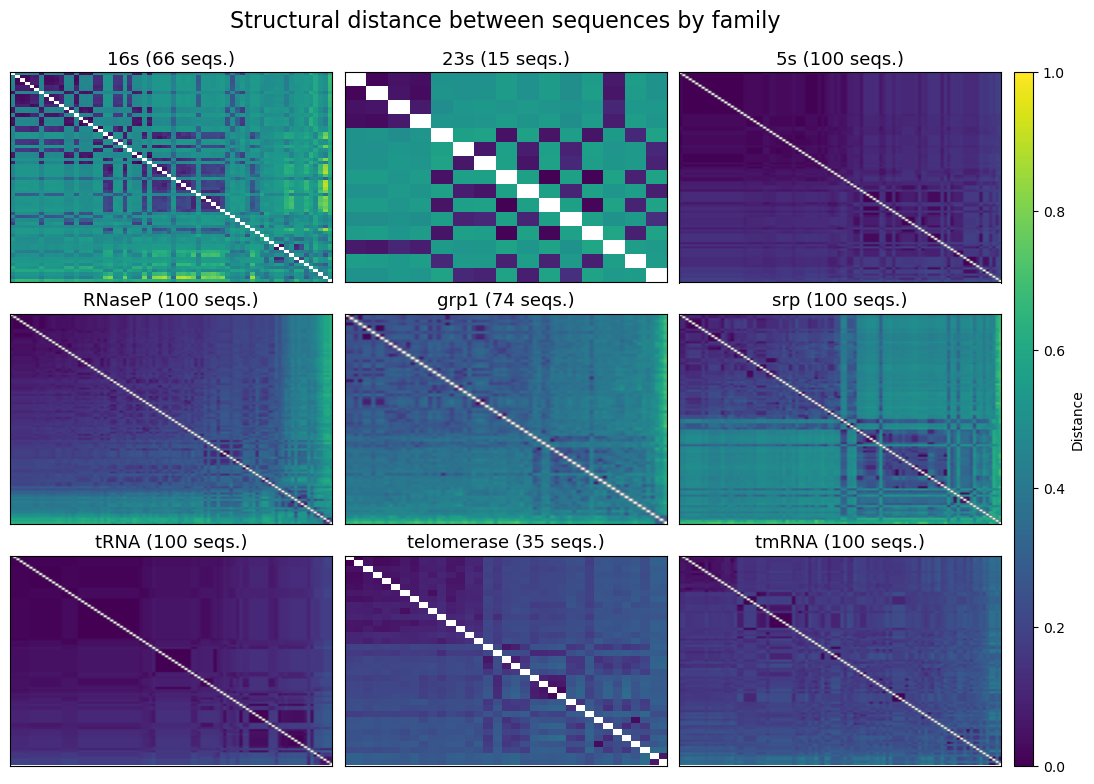

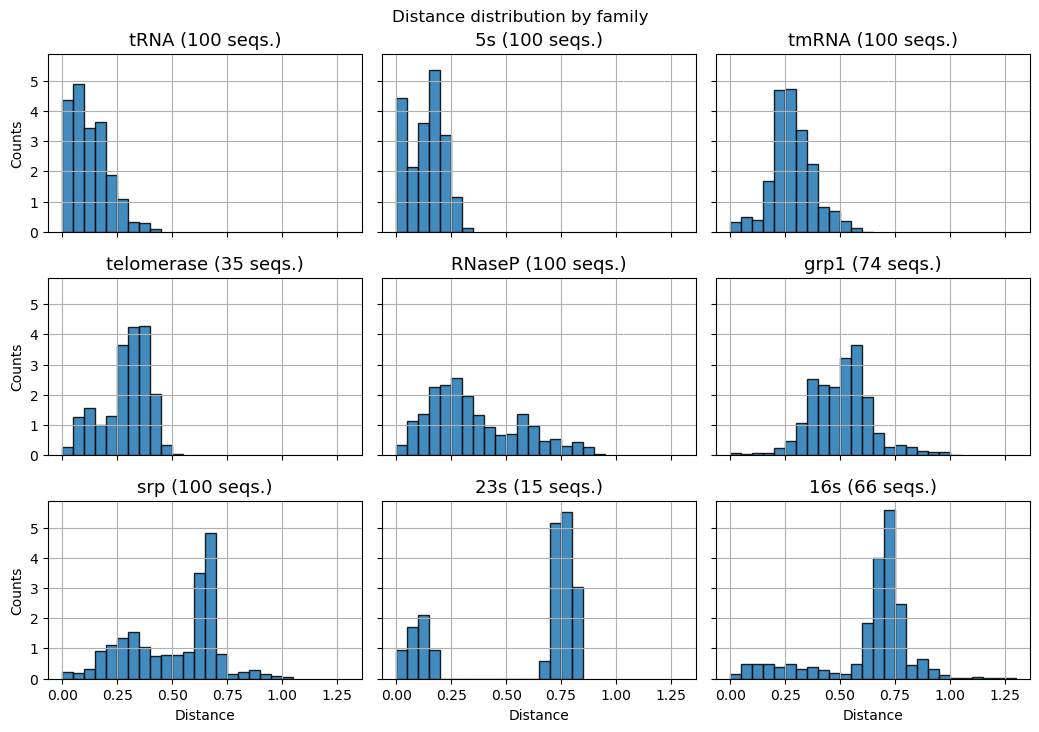

In [14]:
# 5) visualización heatmaps + histogramas
dists = [dist_filt, dist_filt400, dist_filt200, dist_filt100]
for dist in dists:
    ru.plot_heatmaps_with_hist(dist, n_fams=8, order_fams=True, normalized=True)
    ru.plot_histograms(dist, bin_width=0.05)

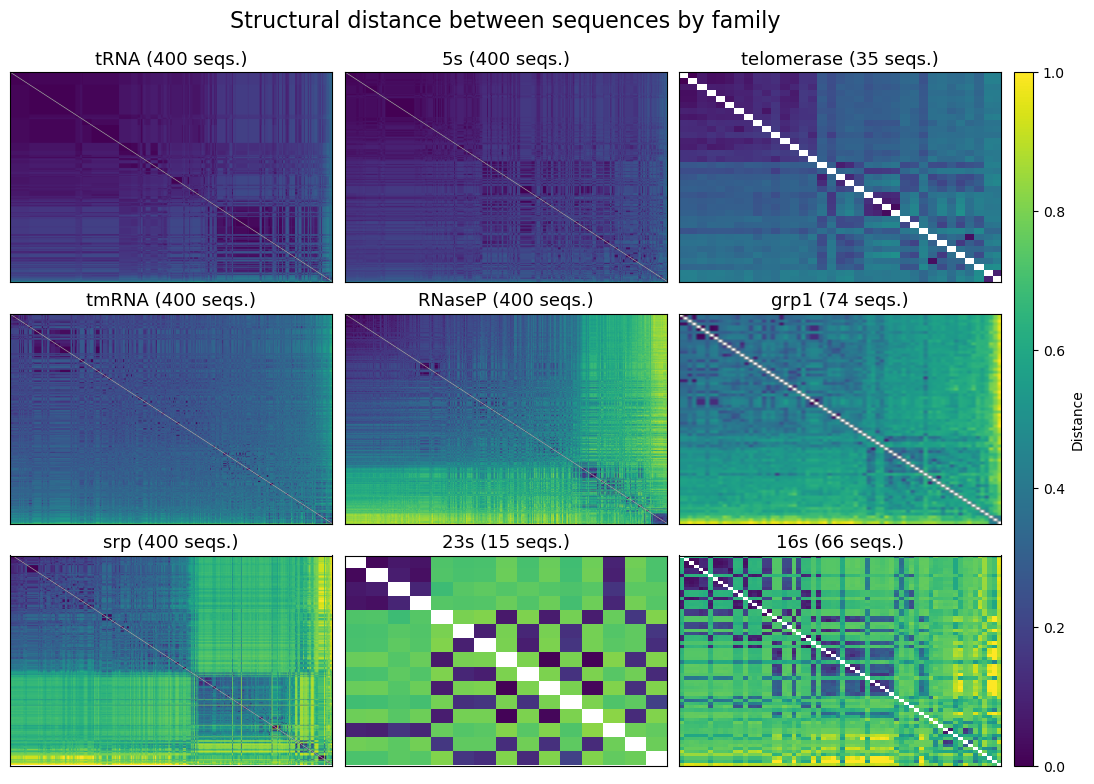

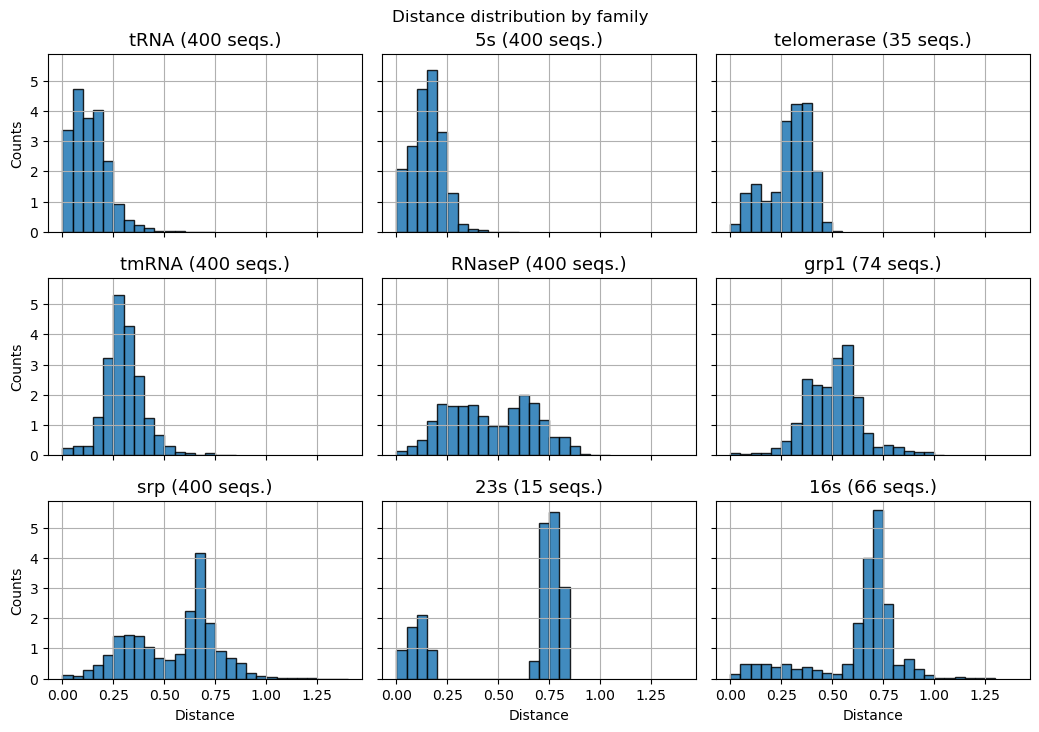

In [15]:
# 5) visualización heatmaps + histogramas
ru.plot_heatmaps_with_hist(dist_filt400, n_fams=8)

# 6) solo histogramas (todas las familias)
ru.plot_histograms(dist_filt400, bin_width=0.05)

In [16]:
# 4) resumen tabular
corrs_filt_summary = ru.summary_table(dist_filt200)
print(60 * "-")
print(corrs_filt_summary.n_seq.sum().item())
print(100 * corrs_filt_summary.n_seq.sum().item() / corrs_summary.n_seq.sum().item())
display(corrs_filt_summary)
print(60 * "-")
display(ru.relative_summary_table(corrs_summary, corrs_filt_summary))

------------------------------------------------------------
1190
30.797101449275363


,Fam,n_seq,mean_dist,min_dist,max_dist
0,5s,200,0.143562,0.000000,0.385827
1,tmRNA,200,0.282381,0.000000,0.682065
2,RNaseP,200,0.434039,0.000000,0.923875
3,tRNA,200,0.126594,0.000000,0.728571
4,srp,200,0.516720,0.000000,1.082192
5,grp1,74,0.505802,0.000000,1.028340
6,16s,66,0.632086,0.013928,1.272727
7,telomerase,35,0.290160,0.002252,0.503778
8,23s,15,0.572299,0.007692,0.824926


------------------------------------------------------------


,Fam,%n_seq,r_min_variation,r_mean_variaton
0,5s,15.588465,NaN,0.884717
1,srp,21.786492,NaN,0.485353
2,tRNA,35.906643,NaN,3.616121
3,tmRNA,43.290043,NaN,0.418775
4,RNaseP,44.052863,NaN,1.101455
5,grp1,100.000000,NaN,1.000000
6,16s,100.000000,1.0,1.000000
7,telomerase,100.000000,1.0,1.000000
8,23s,100.000000,1.0,1.000000


/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/ArchiveII_seq-struc_similarity/struc_dist/rna_utils.py:452: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.96, 0.9])


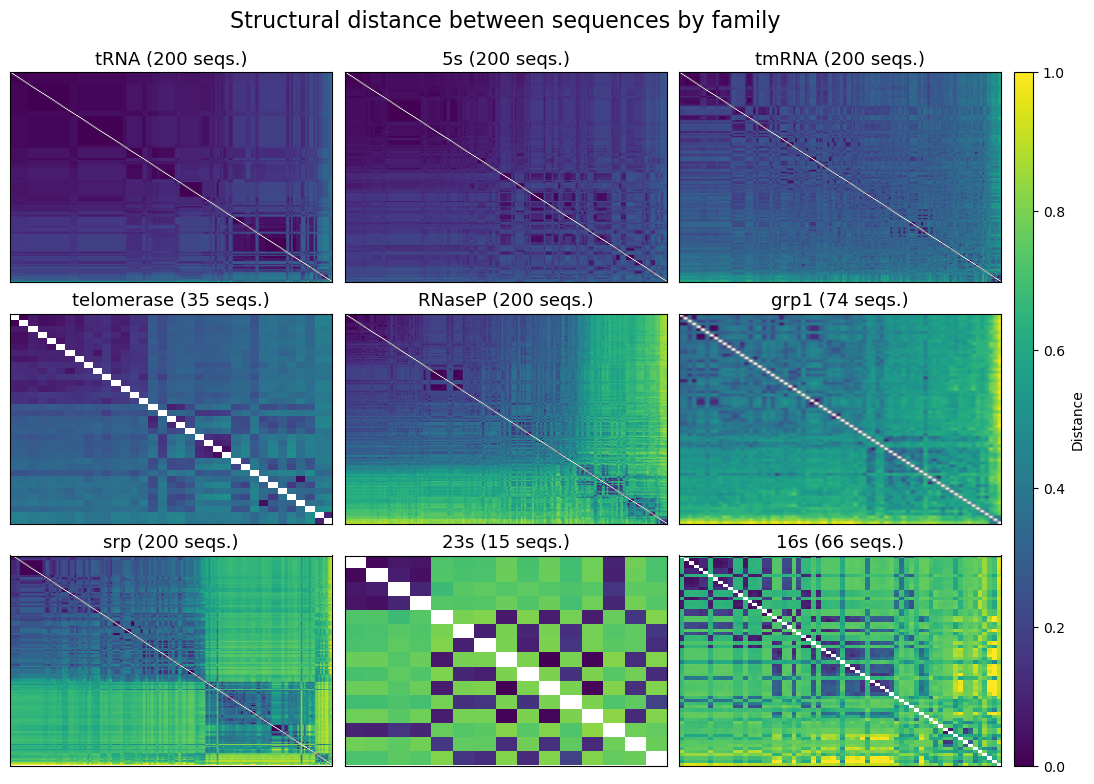

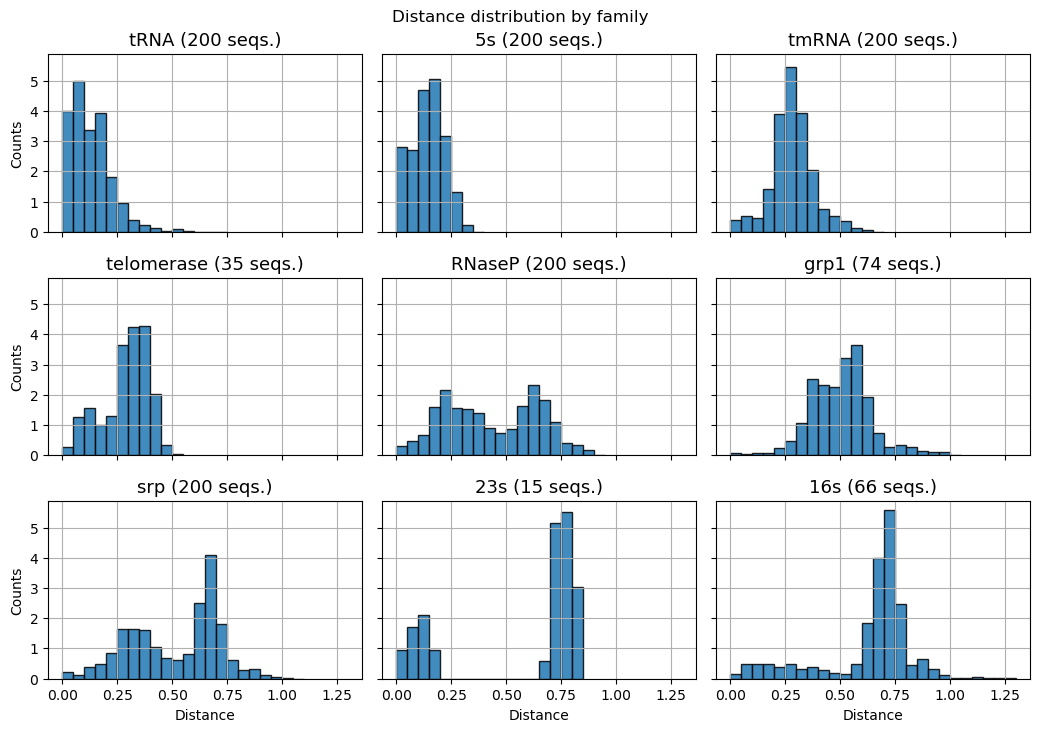

In [17]:
# 5) visualización heatmaps + histogramas
ru.plot_heatmaps_with_hist(dist_filt200, n_fams=8)

# 6) solo histogramas (todas las familias)
ru.plot_histograms(dist_filt200, bin_width=0.05)

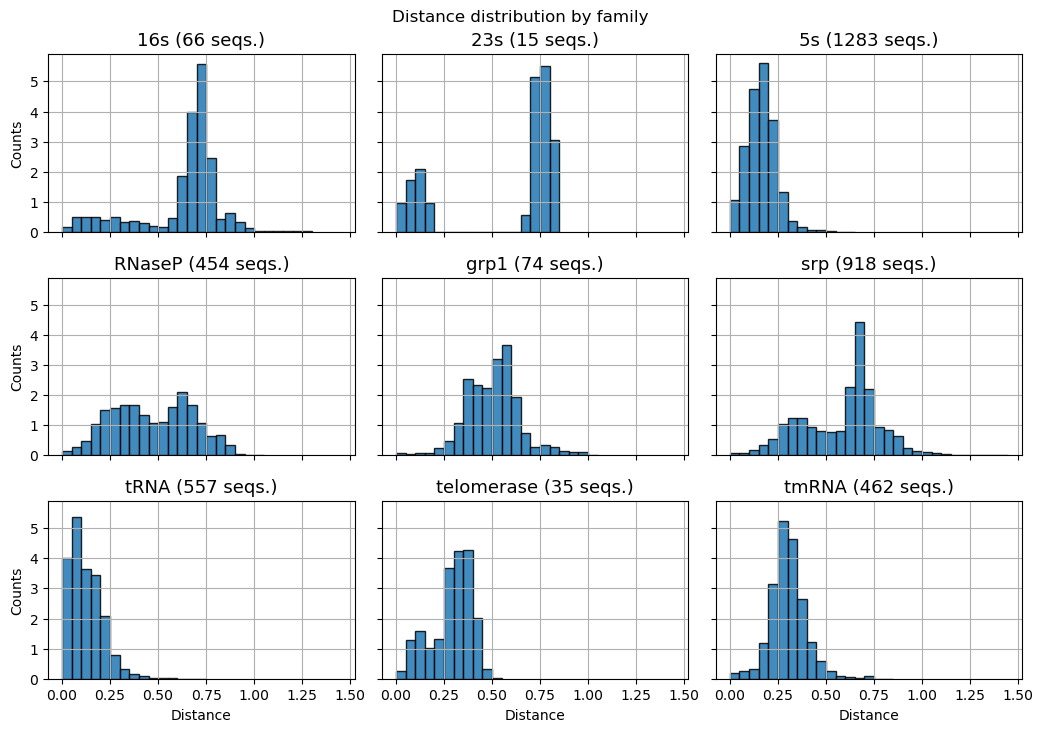

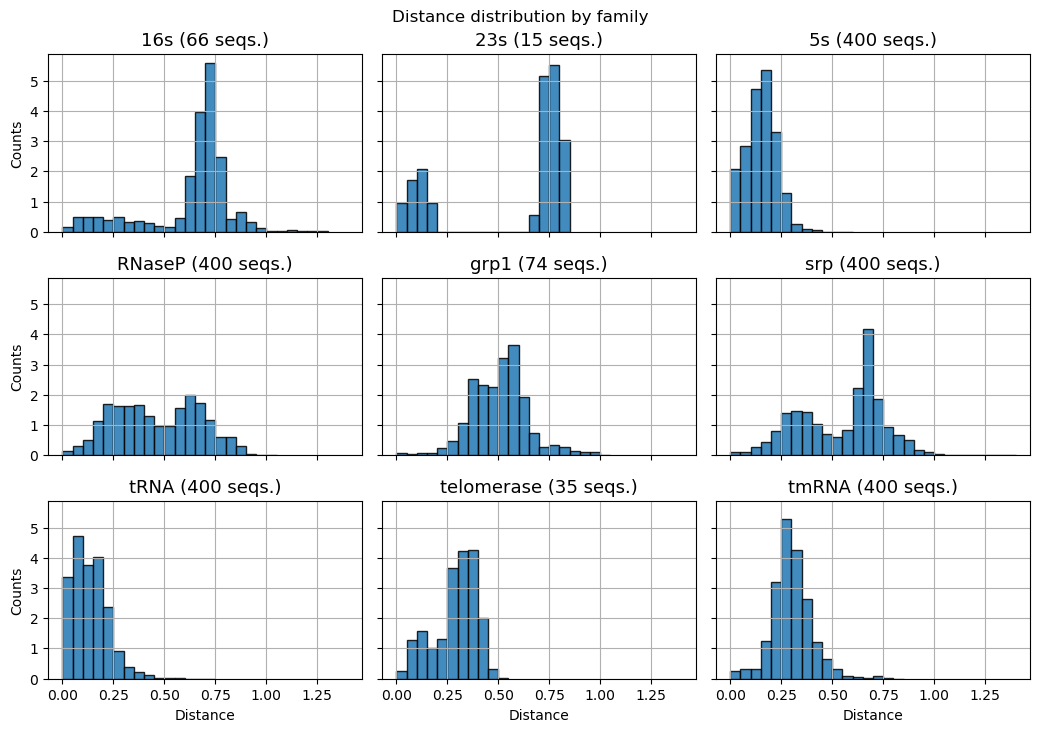

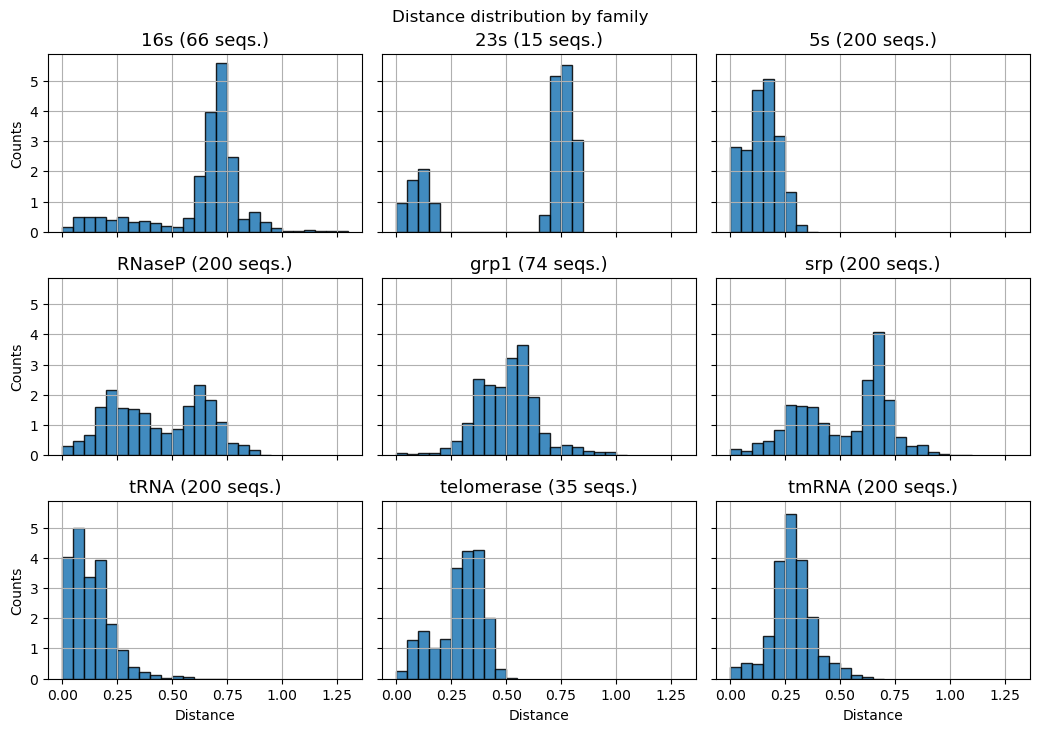

In [18]:
ru.plot_histograms(distances, bin_width=0.05, ordered=False)
ru.plot_histograms(dist_filt400, bin_width=0.05, ordered=False)
ru.plot_histograms(dist_filt200, bin_width=0.05, ordered=False)

# Guardo dfs

In [19]:
# 1. Obtener el conjunto de todos los IDs usados en todos los DataFrames del diccionario
all_ids = set()
for df in dist_filt400.values():
    all_ids.update(df.index)

# 2. Convertir a lista ordenada si querés controlar el orden
all_ids = sorted(all_ids)

# 3. Subseleccionar el DataFrame original
filtered_corr400 = dist.loc[all_ids, all_ids]

# 4. (Opcional) Verificar que la matriz resultante es cuadrada y simétrica
assert filtered_corr400.shape[0] == filtered_corr400.shape[1]
assert (filtered_corr400.values == filtered_corr400.values.T).all()

# 5. Ahora `filtered_corr` es el nuevo DataFrame con sólo los IDs usados
print(filtered_corr400.shape)

AttributeError: 'dict' object has no attribute 'loc'

In [ ]:
# filtered_corr400.to_hdf(
#     "../../data/rnadist_filtered400.h5", key="filtered_dist400", mode="w"
# )

In [ ]:
# 1. Obtener el conjunto de todos los IDs usados en todos los DataFrames del diccionario
all_ids = set()
for df in dist_filt200.values():
    all_ids.update(df.index)

# 2. Convertir a lista ordenada si querés controlar el orden
all_ids = sorted(all_ids)

# 3. Subseleccionar el DataFrame original
filtered_corr200 = dist.loc[all_ids, all_ids]

# 4. (Opcional) Verificar que la matriz resultante es cuadrada y simétrica
assert filtered_corr200.shape[0] == filtered_corr200.shape[1]
assert (filtered_corr200.values == filtered_corr200.values.T).all()

# 5. Ahora `filtered_corr` es el nuevo DataFrame con sólo los IDs usados
print(filtered_corr200.shape)

In [ ]:
# filtered_corr200.to_hdf(
#     "../../data/rnadist_filtered200.h5", key="filtered_dist200", mode="w"
# )